### Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score , confusion_matrix
from sklearn.metrics import classification_report

In [3]:
import nltk
from nltk.corpus import stopwords 
from collections import Counter

### Load the dataset

In [4]:
df = pd.read_csv('mail_data.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


### Exploring The Dataset, Drop Duplicates and Gathering Useful Information About The Dataset 

In [5]:
df.describe()

,Unnamed: 0,label_num
count,5171.000000,5171.000000
mean,2585.000000,0.289886
std,1492.883452,0.453753
min,0.000000,0.000000
25%,1292.500000,0.000000
50%,2585.000000,0.000000
75%,3877.500000,1.000000
max,5170.000000,1.000000


In [6]:
df.shape

(5171, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 5.3 MB


In [8]:
df = df.drop_duplicates()

In [9]:
df['label_num'].value_counts()

label_num
0    3672
1    1499
Name: count, dtype: int64

### Data Visualization Using Seaborn and Other Libraries

C:\Users\Nano Computech\AppData\Local\Temp\ipykernel_11588\1218718049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_num', data=df, palette=['#1e3a8a', '#64748b'])


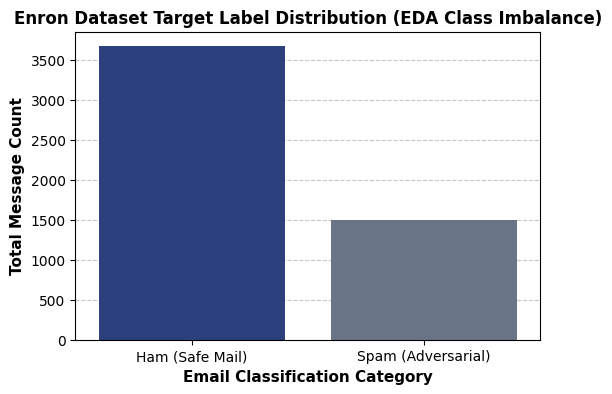

In [10]:
# Set up a clean, professional figure size
plt.figure(figsize=(6, 4))

# Plot the distribution using specific colors (Navy for Ham, Grey for Spam)
sns.countplot(x='label_num', data=df, palette=['#1e3a8a', '#64748b'])

# Format axes and titles clearly
plt.xlabel('Email Classification Category', fontsize=11, fontweight='bold')
plt.ylabel('Total Message Count', fontsize=11, fontweight='bold')
plt.title('Enron Dataset Target Label Distribution (EDA Class Imbalance)', fontsize=12, fontweight='bold')

# CORRECTED AXIS LABELS: Explicitly map 0 to Ham and 1 to Spam
plt.xticks(ticks=[0, 1], labels=['Ham (Safe Mail)', 'Spam (Adversarial)'])

# Show grid lines along the y-axis for better readability
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

# Save the visualization to insert into Section 2.1 of your report
plt.savefig('dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### The 4^th Step is Data Preprocessing

In [11]:
# 1. Correct the column names so Python looks for 'ham' and 'spam' in the 'label' column
# Mapping 'ham' to 0 and 'spam' to 1 is the standard approach
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 2. Clean out any hidden missing or empty rows from your data matrices
df = df.dropna(subset=['text', 'label_num'])

# 3. Separate your clean data into X (features) and y (target labels)
X = df['text'].astype(str)
y = df['label_num'].astype(int)

df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


### Splitting Data to Train and Test Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y
)

### Feature Extraction - TF-IDF

In [13]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

### ▶️ Model Training Using Algorithms

In [14]:
# Initialize the model with balanced weights to handle class sizes automatically
model = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model using the features and labels generated from your preprocessing step
model.fit(X_train_features, y_train)

# Display the top rows of your dataframe to verify
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


### After setting the model, The model is evaluated

In [15]:
# 1. Ensure correct mapping is applied once to the entire dataframe
# Mapping 'ham' to 0 and 'spam' to 1 is the standard approach
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df = df.dropna(subset=['text', 'label_num'])

# 2. Re-vectorize and Split
X = df['text'].astype(str)
y = df['label_num'].astype(int)

# Use stratify=y to ensure both classes are represented in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y
)

# Feature extraction
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

# Safety check
if y_train.nunique() < 2:
    raise ValueError("The training data contains only one class. Check your dataset.")

# 3. Fit the model
model.fit(X_train_features, y_train)

# 4. Predict
prediction_on_training_data = model.predict(X_train_features)
prediction_on_test_data = model.predict(X_test_features)

# 5. Evaluate and Print Accuracy
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

print("=" * 50)
print(f'Accuracy on training data: {accuracy_on_training_data * 100:.2f} %')
print(f'Accuracy on test data: {accuracy_on_test_data * 100:.2f} %')
print("=" * 50)

# 6. Detailed Performance Metrics (Add this to complete evaluation)
print("\n📊 CLASSIFICATION REPORT:")
# Maps target 0 to 'Ham' and target 1 to 'Spam'
print(classification_report(y_test, prediction_on_test_data, target_names=['Ham', 'Spam']))

print("🧩 CONFUSION MATRIX:")
print(confusion_matrix(y_test, prediction_on_test_data))
print("=" * 50)

Accuracy on training data: 97.94 %
Accuracy on test data: 95.07 %

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       1.00      0.93      0.96       735
        Spam       0.86      1.00      0.92       300

    accuracy                           0.95      1035
   macro avg       0.93      0.96      0.94      1035
weighted avg       0.96      0.95      0.95      1035

🧩 CONFUSION MATRIX:
[[685  50]
 [  1 299]]


### Confusion Matrix Visualization If it needed

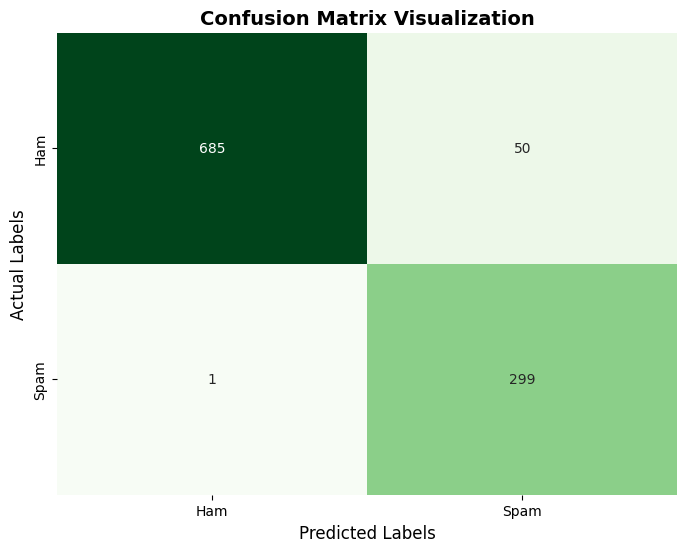

In [16]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, prediction_on_test_data)

# Set up the figure size
plt.figure(figsize=(8, 6))

# CORRECTED LABELS: 0 is Ham, 1 is Spam (matching numerical order [0, 1])
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])

# Add labels and formatting
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('Actual Labels', fontsize=12)
plt.title('Confusion Matrix Visualization', fontsize=14, fontweight='bold')

# Show the plot smoothly
plt.show()

### Calculating and Displaying Error Metrics

In [17]:
# Generate the classification report with the correct index labels (0 = Ham, 1 = Spam)
classification_rep = classification_report(y_test, prediction_on_test_data, target_names=['Ham', 'Spam'])

print("Classification Report:")
print(classification_rep)

# 1. Predict on the training data
y_train_pred = model.predict(X_train_features)

print("--- TRAINING SET PERFORMANCE ---")
print(classification_report(y_train, y_train_pred, target_names=['Ham', 'Spam']))

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.93      0.96       735
        Spam       0.86      1.00      0.92       300

    accuracy                           0.95      1035
   macro avg       0.93      0.96      0.94      1035
weighted avg       0.96      0.95      0.95      1035

--- TRAINING SET PERFORMANCE ---
              precision    recall  f1-score   support

         Ham       1.00      0.97      0.99      2937
        Spam       0.93      1.00      0.97      1199

    accuracy                           0.98      4136
   macro avg       0.97      0.99      0.98      4136
weighted avg       0.98      0.98      0.98      4136



### Now we can make prediction using text message

In [18]:
# 1. Clean raw text input string 
input_your_mail = "URGENT! We are trying to contact you. Last weekends draw shows that you have won a £900 prize GUARANTEED. Call 09061701939. Claim code S89. Valid 12hrs only".strip()

# 2. Transform the text to match the model's exact matrix features
input_data_feature = feature_extraction.transform([input_your_mail])

# 3. Predict the exact label (0 or 1)
prediction = model.predict(input_data_feature)

# 4. Extract classification certainty percentages
probabilities = model.predict_proba(input_data_feature)[0]
ham_probability = probabilities[0] * 100
spam_probability = probabilities[1] * 100

print("-" * 50)
print(f"Analyzing Message: '{input_your_mail[:60]}...'")
print("-" * 50)

# 5. Conditional Output matching your mapping (0 = Ham, 1 = Spam)
if prediction[0] == 0:
    print(f"Result: ✅ Ham mail")
    print(f"Model Confidence: {ham_probability:.2f}% sure it is safe.")
else:
    print(f"Result: 🚨 Spam mail")
    print(f"Model Confidence: {spam_probability:.2f}% sure it is spam.")
print("-" * 50)

--------------------------------------------------
Analyzing Message: 'URGENT! We are trying to contact you. Last weekends draw sho...'
--------------------------------------------------
Result: 🚨 Spam mail
Model Confidence: 74.44% sure it is spam.
--------------------------------------------------
